In [ ]:
Name: Lukhi Laksh Nareshbhai
Enrollment Number: SR25MSAD016

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [7]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    if len(filenames) > 0:
        print("Number of files:", len(filenames))

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/gpiosenka
/kaggle/input/datasets/gpiosenka/sports-classification
Number of files: 2
/kaggle/input/datasets/gpiosenka/sports-classification/valid
/kaggle/input/datasets/gpiosenka/sports-classification/valid/bobsled
Number of files: 5
/kaggle/input/datasets/gpiosenka/sports-classification/valid/hurdles
Number of files: 5
/kaggle/input/datasets/gpiosenka/sports-classification/valid/snow boarding
Number of files: 5
/kaggle/input/datasets/gpiosenka/sports-classification/valid/fly fishing
Number of files: 5
/kaggle/input/datasets/gpiosenka/sports-classification/valid/luge
Number of files: 5
/kaggle/input/datasets/gpiosenka/sports-classification/valid/sidecar racing
Number of files: 5
/kaggle/input/datasets/gpiosenka/sports-classification/valid/ampute football
Number of files: 5
/kaggle/input/datasets/gpiosenka/sports-classification/valid/volleyball
Number of files: 5
/kaggle/input/datasets/gpiosenka/sports-classification/valid/billi

In [8]:
DATASET_PATH = "/kaggle/input/sports-classification"

train_dir = os.path.join(DATASET_PATH, "train")
valid_dir = os.path.join(DATASET_PATH, "valid")
test_dir = os.path.join(DATASET_PATH, "test")

print("Train:", train_dir)
print("Validation:", valid_dir)
print("Test:", test_dir)

Train: /kaggle/input/sports-classification/train
Validation: /kaggle/input/sports-classification/valid
Test: /kaggle/input/sports-classification/test


In [11]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [14]:
import os

train_dir = None
valid_dir = None
test_dir = None

for root, dirs, files in os.walk("/kaggle/input"):
    folder = os.path.basename(root).lower()

    if folder == "train":
        train_dir = root

    elif folder in ["valid", "validation"]:
        valid_dir = root

    elif folder == "test":
        test_dir = root

print("TRAIN:", train_dir)
print("VALID:", valid_dir)
print("TEST :", test_dir)

TRAIN: /kaggle/input/datasets/gpiosenka/sports-classification/train
VALID: /kaggle/input/datasets/gpiosenka/sports-classification/valid
TEST : /kaggle/input/datasets/gpiosenka/sports-classification/test


In [15]:
classes = sorted([
    folder for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

print("Total number of classes:", len(classes))

for i, cls in enumerate(classes):
    print(i + 1, cls)

Total number of classes: 100
1 air hockey
2 ampute football
3 archery
4 arm wrestling
5 axe throwing
6 balance beam
7 barell racing
8 baseball
9 basketball
10 baton twirling
11 bike polo
12 billiards
13 bmx
14 bobsled
15 bowling
16 boxing
17 bull riding
18 bungee jumping
19 canoe slamon
20 cheerleading
21 chuckwagon racing
22 cricket
23 croquet
24 curling
25 disc golf
26 fencing
27 field hockey
28 figure skating men
29 figure skating pairs
30 figure skating women
31 fly fishing
32 football
33 formula 1 racing
34 frisbee
35 gaga
36 giant slalom
37 golf
38 hammer throw
39 hang gliding
40 harness racing
41 high jump
42 hockey
43 horse jumping
44 horse racing
45 horseshoe pitching
46 hurdles
47 hydroplane racing
48 ice climbing
49 ice yachting
50 jai alai
51 javelin
52 jousting
53 judo
54 lacrosse
55 log rolling
56 luge
57 motorcycle racing
58 mushing
59 nascar racing
60 olympic wrestling
61 parallel bar
62 pole climbing
63 pole dancing
64 pole vault
65 polo
66 pommel horse
67 rings
68 roc

In [16]:
import os

classes = sorted([
    folder for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

print("Total number of classes:", len(classes))

print("\nAll Sports Classes:")
for i, cls in enumerate(classes):
    print(i + 1, cls)

Total number of classes: 100

All Sports Classes:
1 air hockey
2 ampute football
3 archery
4 arm wrestling
5 axe throwing
6 balance beam
7 barell racing
8 baseball
9 basketball
10 baton twirling
11 bike polo
12 billiards
13 bmx
14 bobsled
15 bowling
16 boxing
17 bull riding
18 bungee jumping
19 canoe slamon
20 cheerleading
21 chuckwagon racing
22 cricket
23 croquet
24 curling
25 disc golf
26 fencing
27 field hockey
28 figure skating men
29 figure skating pairs
30 figure skating women
31 fly fishing
32 football
33 formula 1 racing
34 frisbee
35 gaga
36 giant slalom
37 golf
38 hammer throw
39 hang gliding
40 harness racing
41 high jump
42 hockey
43 horse jumping
44 horse racing
45 horseshoe pitching
46 hurdles
47 hydroplane racing
48 ice climbing
49 ice yachting
50 jai alai
51 javelin
52 jousting
53 judo
54 lacrosse
55 log rolling
56 luge
57 motorcycle racing
58 mushing
59 nascar racing
60 olympic wrestling
61 parallel bar
62 pole climbing
63 pole dancing
64 pole vault
65 polo
66 pommel 

In [17]:
selected_classes = classes[:5]

print("Selected Classes:")
for i, cls in enumerate(selected_classes):
    print(i + 1, cls)

Selected Classes:
1 air hockey
2 ampute football
3 archery
4 arm wrestling
5 axe throwing


In [18]:
print("Image count for selected classes:\n")

for cls in selected_classes:
    
    train_count = len(os.listdir(os.path.join(train_dir, cls)))
    valid_count = len(os.listdir(os.path.join(valid_dir, cls)))
    test_count = len(os.listdir(os.path.join(test_dir, cls)))
    
    print(
        f"{cls}: "
        f"Train = {train_count}, "
        f"Validation = {valid_count}, "
        f"Test = {test_count}"
    )

Image count for selected classes:

air hockey: Train = 112, Validation = 5, Test = 5
ampute football: Train = 112, Validation = 5, Test = 5
archery: Train = 132, Validation = 5, Test = 5
arm wrestling: Train = 99, Validation = 5, Test = 5
axe throwing: Train = 113, Validation = 5, Test = 5


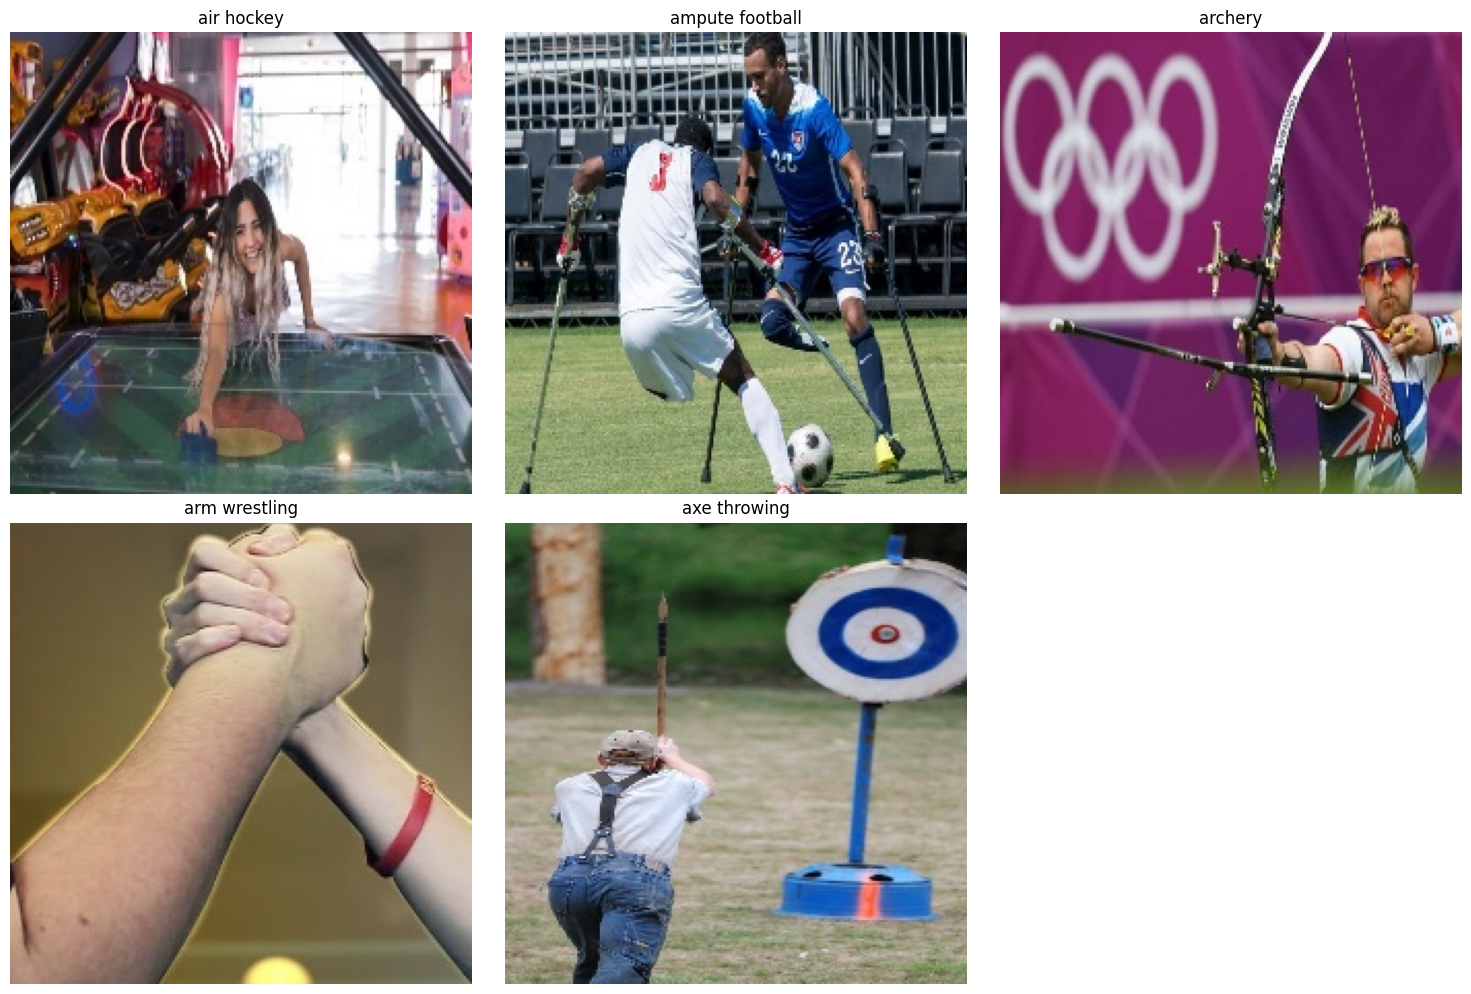

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

for i, cls in enumerate(selected_classes):
    
    folder_path = os.path.join(train_dir, cls)
    image_name = os.listdir(folder_path)[0]
    image_path = os.path.join(folder_path, image_name)
    
    image = plt.imread(image_path)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.layers import (
    Dense,
    GlobalAveragePooling2D,
    Dropout
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [5]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.layers import (
    Dense,
    GlobalAveragePooling2D,
    Dropout
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow version: 2.20.0
Libraries imported successfully!


In [9]:
import os

# Find the dataset folders automatically
train_dir = None
valid_dir = None
test_dir = None

for root, dirs, files in os.walk("/kaggle/input"):
    folder_name = os.path.basename(root).lower()

    if folder_name == "train":
        train_dir = root

    elif folder_name in ["valid", "validation"]:
        valid_dir = root

    elif folder_name == "test":
        test_dir = root

print("Train directory:", train_dir)
print("Validation directory:", valid_dir)
print("Test directory:", test_dir)


# Check that the folders were found
if train_dir is None:
    raise FileNotFoundError("Training folder was not found. Make sure the dataset is attached.")

if valid_dir is None:
    raise FileNotFoundError("Validation folder was not found. Make sure the dataset is attached.")

if test_dir is None:
    raise FileNotFoundError("Test folder was not found. Make sure the dataset is attached.")


# Get all available classes
classes = sorted([
    folder for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

print("\nTotal number of classes:", len(classes))

# Select 5 classes
selected_classes = classes[:5]

print("\nSelected classes:")
for i, cls in enumerate(selected_classes):
    print(i + 1, cls)

Train directory: /kaggle/input/datasets/gpiosenka/sports-classification/train
Validation directory: /kaggle/input/datasets/gpiosenka/sports-classification/valid
Test directory: /kaggle/input/datasets/gpiosenka/sports-classification/test

Total number of classes: 100

Selected classes:
1 air hockey
2 ampute football
3 archery
4 arm wrestling
5 axe throwing


In [7]:

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

print("Data generators created successfully!")

Data generators created successfully!


In [10]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=selected_classes,
    class_mode="categorical",
    shuffle=True
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=selected_classes,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=selected_classes,
    class_mode="categorical",
    shuffle=False
)

Found 568 images belonging to 5 classes.
Found 25 images belonging to 5 classes.
Found 25 images belonging to 5 classes.


In [12]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("MobileNetV2 loaded successfully!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MobileNetV2 loaded successfully!


In [13]:
base_model.trainable = False

print("Base model layers are frozen.")

Base model layers are frozen.


In [15]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)

x = Dropout(0.5)(x)

output = Dense(
    len(selected_classes),
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

print("Classification layers added successfully!")

Classification layers added successfully!


In [16]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7
)

print("Callbacks created successfully!")

Callbacks created successfully!


In [20]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 841ms/step - accuracy: 0.9014 - loss: 0.3465 - val_accuracy: 1.0000 - val_loss: 0.0799 - learning_rate: 1.0000e-04
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 840ms/step - accuracy: 0.9032 - loss: 0.3348 - val_accuracy: 1.0000 - val_loss: 0.0609 - learning_rate: 1.0000e-04
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 839ms/step - accuracy: 0.9049 - loss: 0.3094 - val_accuracy: 1.0000 - val_loss: 0.0476 - learning_rate: 1.0000e-04
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 845ms/step - accuracy: 0.9190 - loss: 0.2623 - val_accuracy: 1.0000 - val_loss: 0.0394 - learning_rate: 1.0000e-04
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 871ms/step - accuracy: 0.9366 - loss: 0.2574 - val_accuracy: 1.0000 - val_loss: 0.0354 - learning_rate: 1.0000e-04
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 843ms/step - accuracy: 0.9173 - loss: 0.2534 - val_accuracy: 1.0000 - val_loss: 0.0296 - learning_rate: 1.0000e-04
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 866ms/step - acc

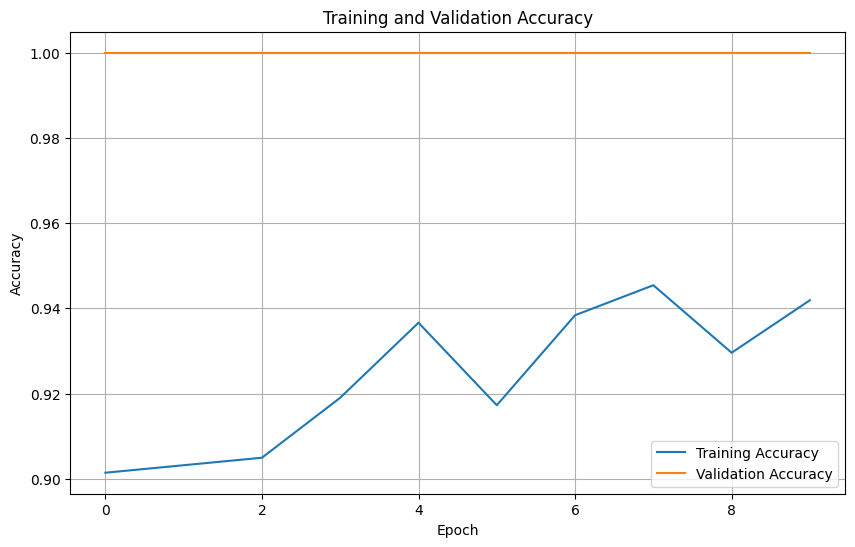

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid()
plt.show()

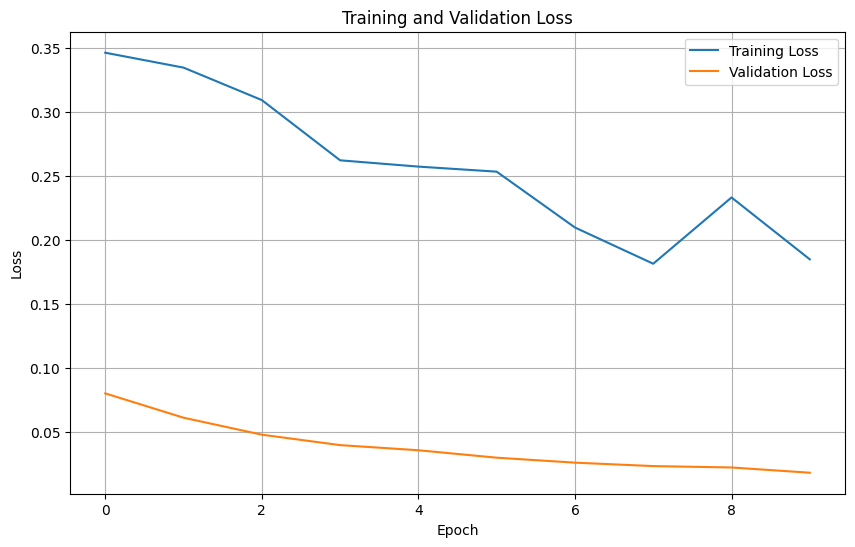

In [23]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid()
plt.show()

In [24]:
base_model.trainable = True

print("MobileNetV2 has been unfrozen.")

MobileNetV2 has been unfrozen.


In [25]:
for layer in base_model.layers[:100]:
    layer.trainable = False

print("First 100 layers are frozen.")

First 100 layers are frozen.


In [26]:
total_layers = len(base_model.layers)

trainable_layers = sum(
    layer.trainable for layer in base_model.layers
)

print("Total MobileNetV2 layers:", total_layers)
print("Trainable layers:", trainable_layers)

Total MobileNetV2 layers: 154
Trainable layers: 54


In [28]:
model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning.")

Model recompiled for fine-tuning.


In [29]:
fine_tune_history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.7500 - loss: 0.6550 - val_accuracy: 1.0000 - val_loss: 0.0151 - learning_rate: 1.0000e-05
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.8116 - loss: 0.5757 - val_accuracy: 1.0000 - val_loss: 0.0135 - learning_rate: 1.0000e-05
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.8715 - loss: 0.4370 - val_accuracy: 1.0000 - val_loss: 0.0123 - learning_rate: 1.0000e-05
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.8451 - loss: 0.4592 - val_accuracy: 1.0000 - val_loss: 0.0112 - learning_rate: 1.0000e-05
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.8944 - loss: 0.3551 - val_accuracy: 1.0000 - val_loss: 0.0101 - learning_rate: 1.0000e-05
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9085 - loss: 0.3319 - val_accuracy: 1.0000 - val_loss: 0.0092 - learning_rate: 1.0000e-05
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9173 - loss:

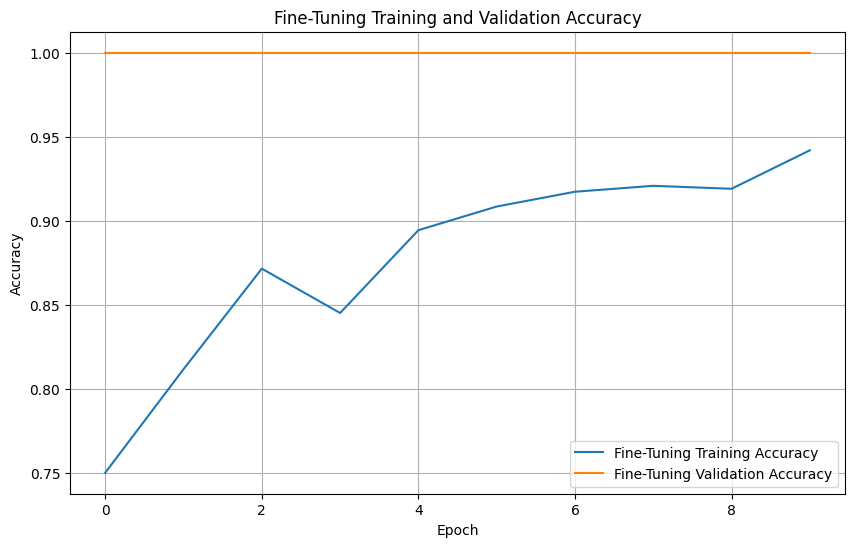

In [30]:
plt.figure(figsize=(10, 6))

plt.plot(
    fine_tune_history.history["accuracy"],
    label="Fine-Tuning Training Accuracy"
)

plt.plot(
    fine_tune_history.history["val_accuracy"],
    label="Fine-Tuning Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fine-Tuning Training and Validation Accuracy")

plt.legend()
plt.grid()
plt.show()

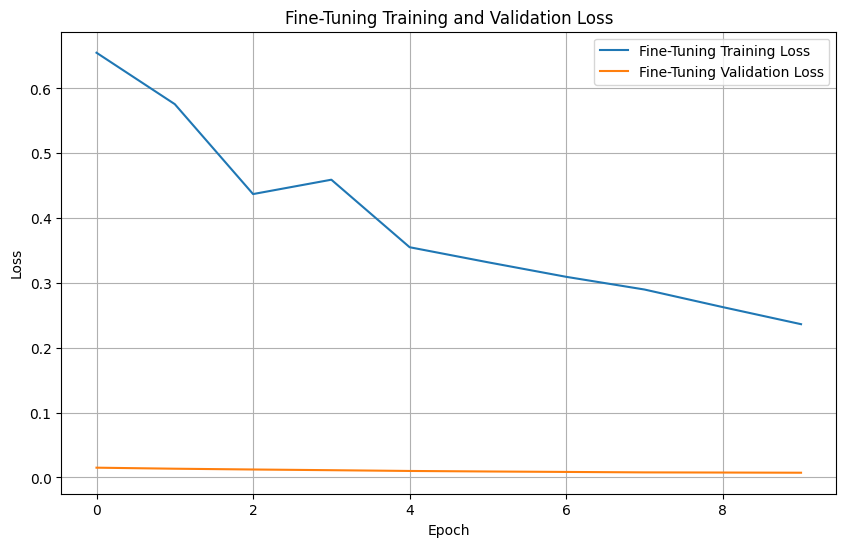

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    fine_tune_history.history["loss"],
    label="Fine-Tuning Training Loss"
)

plt.plot(
    fine_tune_history.history["val_loss"],
    label="Fine-Tuning Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-Tuning Training and Validation Loss")

plt.legend()
plt.grid()
plt.show()

In [32]:
test_loss, test_accuracy = model.evaluate(
    test_generator
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy: {:.2f}%".format(test_accuracy * 100))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 602ms/step - accuracy: 1.0000 - loss: 0.0080
Test Loss: 0.007984609343111515
Test Accuracy: 1.0
Test Accuracy: 100.00%


In [33]:
test_generator.reset()

predictions = model.predict(test_generator)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = test_generator.classes

class_names = list(
    test_generator.class_indices.keys()
)

print("Predictions generated successfully.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predictions generated successfully.


In [34]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

                 precision    recall  f1-score   support

     air hockey       1.00      1.00      1.00         5
ampute football       1.00      1.00      1.00         5
        archery       1.00      1.00      1.00         5
  arm wrestling       1.00      1.00      1.00         5
   axe throwing       1.00      1.00      1.00         5

       accuracy                           1.00        25
      macro avg       1.00      1.00      1.00        25
   weighted avg       1.00      1.00      1.00        25



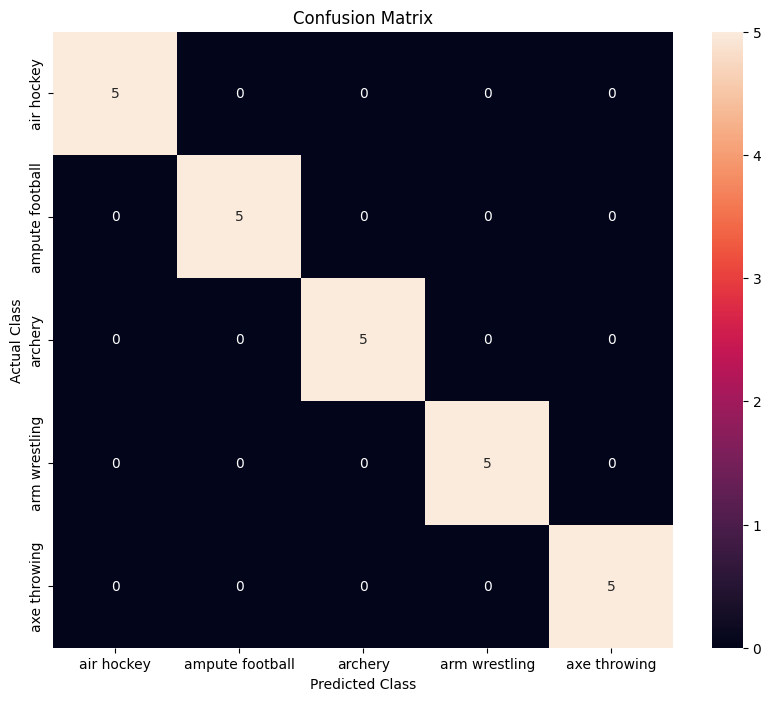

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


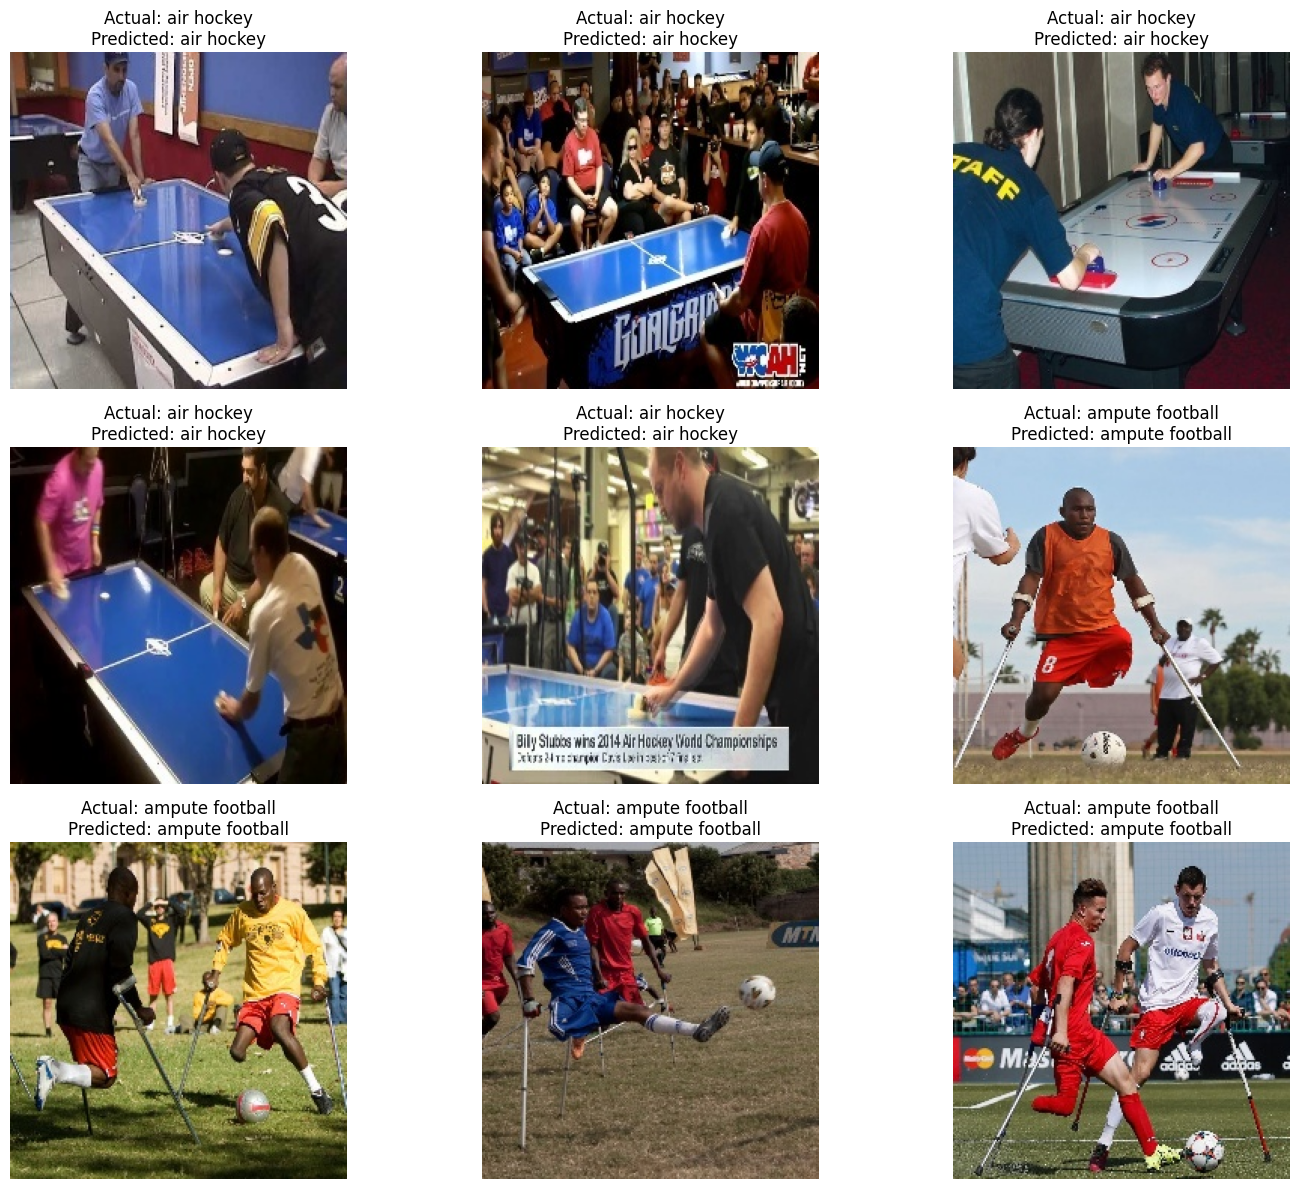

In [37]:
test_generator.reset()

images, labels = next(test_generator)

predictions = model.predict(images)

plt.figure(figsize=(15, 12))

for i in range(min(9, len(images))):

    plt.subplot(3, 3, i + 1)

    image = images[i]

    image = (image - image.min()) / (
        image.max() - image.min()
    )

    plt.imshow(image)

    actual = class_names[
        np.argmax(labels[i])
    ]

    predicted = class_names[
        np.argmax(predictions[i])
    ]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [38]:
model.save(
    "/kaggle/working/sports_classification_mobilenetv2.keras"
)

print("Final model saved successfully!")

Final model saved successfully!


In [39]:
print("=" * 60)
print("SPORTS CLASSIFICATION USING TRANSFER LEARNING")
print("=" * 60)

print("Pre-trained Model :", "MobileNetV2")
print("Number of Classes :", len(selected_classes))
print("Selected Classes  :", selected_classes)
print("Image Size        :", IMG_SIZE)
print("Test Accuracy     :", f"{test_accuracy * 100:.2f}%")

print("=" * 60)

SPORTS CLASSIFICATION USING TRANSFER LEARNING
Pre-trained Model : MobileNetV2
Number of Classes : 5
Selected Classes  : ['air hockey', 'ampute football', 'archery', 'arm wrestling', 'axe throwing']
Image Size        : (224, 224)
Test Accuracy     : 100.00%
